이상치 탐지 및 제거

탐지된 이상치 학생 수: 2명 (0.7%)

이상치 학생 목록:
                       id studentGrade  totalScore  불안 및 우울 문제  심리외상 문제  외현화 문제  자살 및 위기 문제  학교생활적응 문제
0    -ObjIPga9Ue498KCznbL          2학년          96          19       19      24          15         19
228  -ObjSIA3w4dNhS1WXXyX          1학년         108          24       21      24          18         21


C:\Users\user\AppData\Local\Temp\ipykernel_23436\1189024684.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(),


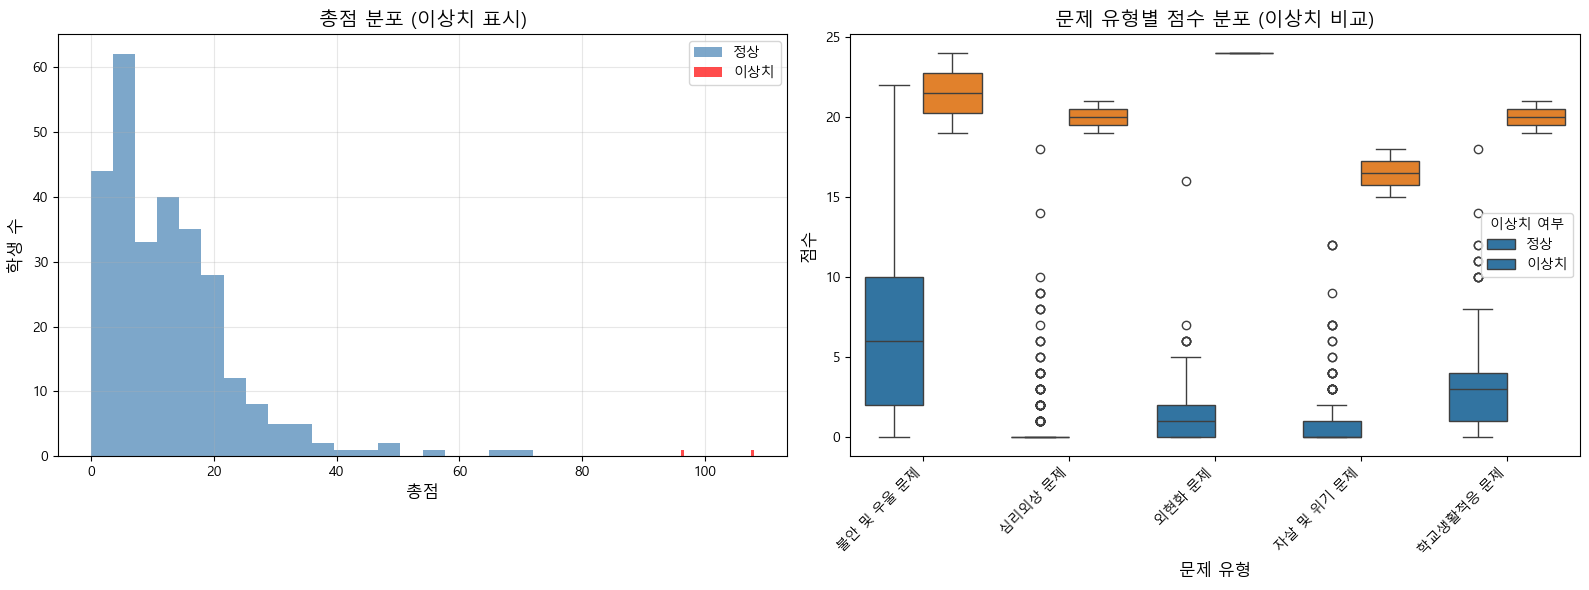


최적 클러스터 수 탐지 중... (이상치 제거 후)


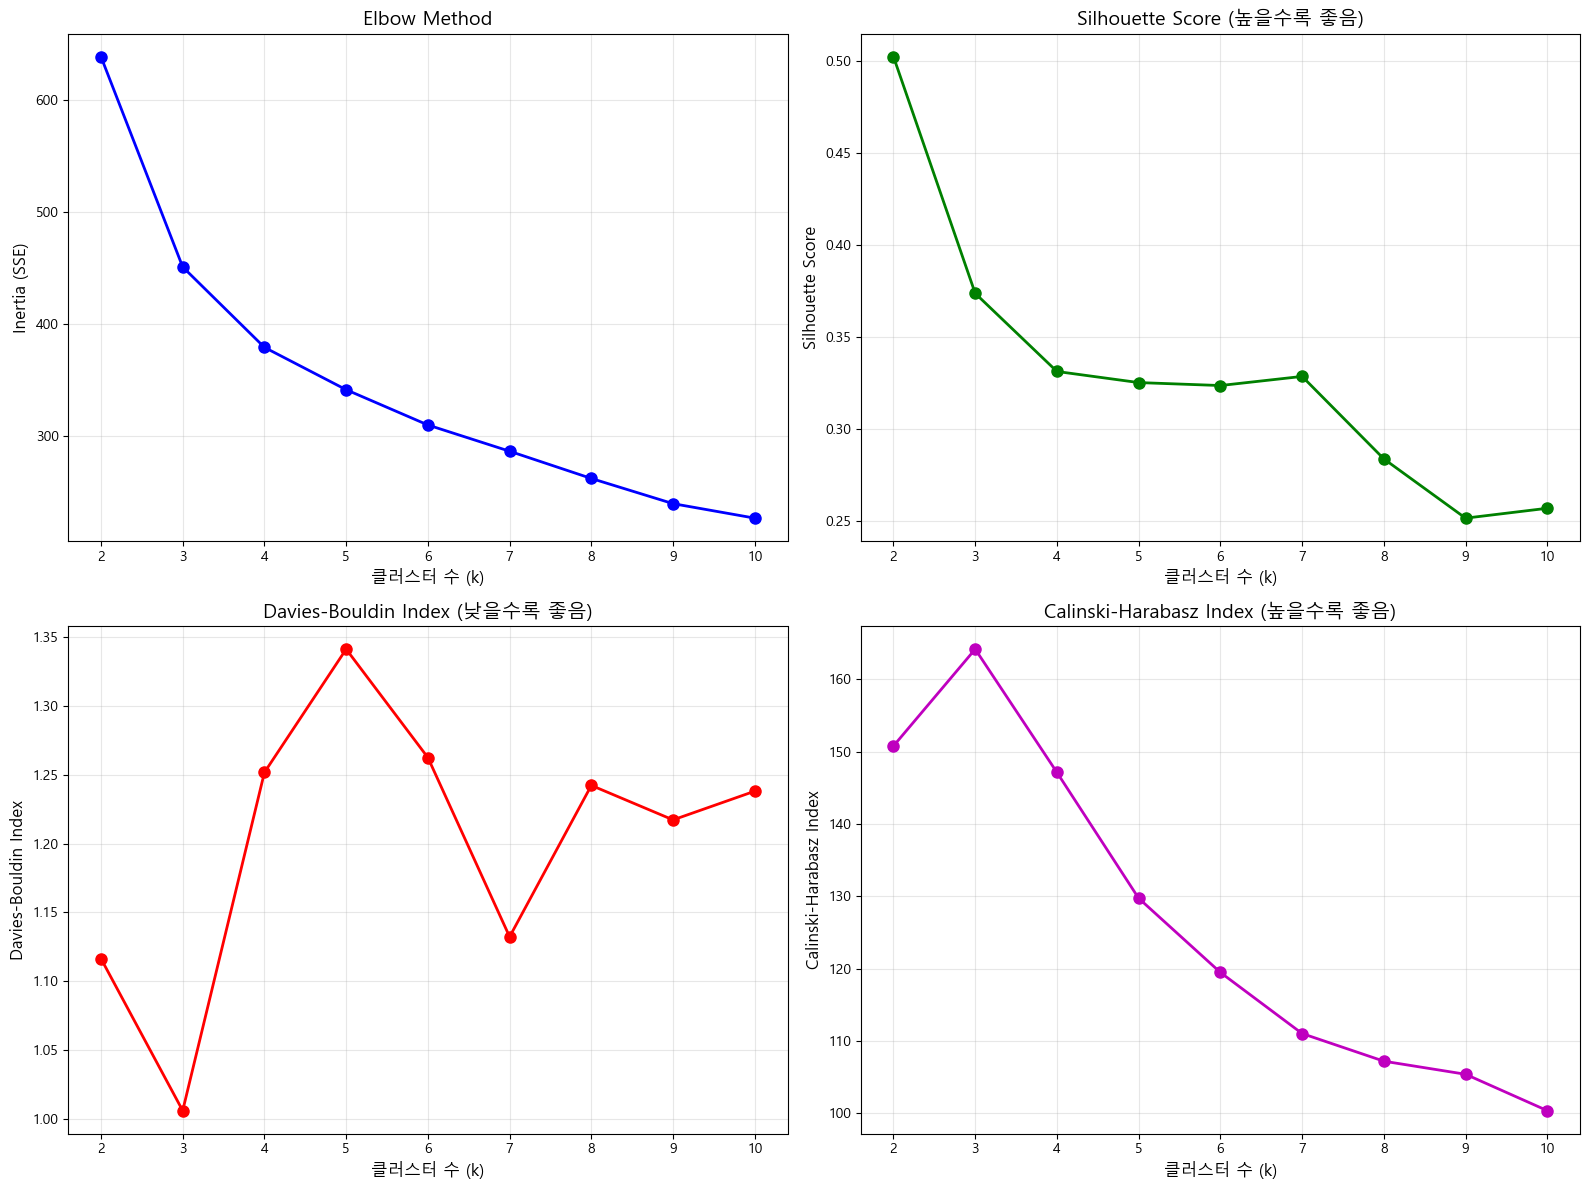


최적 클러스터 수: 3
  - Silhouette Score: 0.374
  - Davies-Bouldin Index: 1.006
  - Calinski-Harabasz Index: 164.175

클러스터별 학생 수:
cluster
0    112
1    162
2      7
Name: count, dtype: int64

클러스터별 특성 요약
        불안 및 우울 문제                    심리외상 문제                    외현화 문제  \
              mean       std count       mean       std count      mean   
cluster                                                                   
0        10.803571  3.309390   112   1.080357  1.811566   112  1.776786   
1         3.376543  2.628122   162   0.271605  0.978176   162  0.635802   
2        17.857143  2.853569     7  10.714286  3.988077     7  5.857143   

                       자살 및 위기 문제                  학교생활적응 문제                  \
             std count       mean       std count       mean       std count   
cluster                                                                        
0        1.68571   112   1.232143  1.649363   112   4.866071  2.170629   112   
1        0.97647   162   0.1604

In [5]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import IsolationForest
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Load data
file = open('./input/data.json', 'r', encoding='utf-8')
data = json.load(file)

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

students_data = data['students']

rows = []
for student_id, info in students_data.items():
    row = info['scores']
    row['studentGrade'] = info['studentGrade']
    row['totalScore'] = info['totalScore']
    row['id'] = student_id
    rows.append(row)

df = pd.DataFrame(rows)
df['grade_num'] = df['studentGrade'].str.extract(r'(\d)').astype(int)

features = ['불안 및 우울 문제', '심리외상 문제', '외현화 문제', '자살 및 위기 문제', '학교생활적응 문제']

# ==========================================
# 이상치 탐지 및 제거
# ==========================================
print("="*80)
print("이상치 탐지 및 제거")
print("="*80)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Isolation Forest로 이상치 탐지
iso_forest = IsolationForest(
    contamination=0.005, random_state=42)  # 상위 5%를 이상치로 간주
outlier_labels = iso_forest.fit_predict(X_scaled)

# 이상치 정보 출력
df['is_outlier'] = outlier_labels == -1
outliers = df[df['is_outlier']]

print(f"\n탐지된 이상치 학생 수: {len(outliers)}명 ({len(outliers)/len(df)*100:.1f}%)")
print("\n이상치 학생 목록:")
print(outliers[['id', 'studentGrade', 'totalScore'] + features].to_string())

# 이상치 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 총점 분포
axes[0].hist(df[~df['is_outlier']]['totalScore'], bins=20,
             alpha=0.7, label='정상', color='steelblue')
axes[0].hist(df[df['is_outlier']]['totalScore'], bins=20,
             alpha=0.7, label='이상치', color='red')
axes[0].set_xlabel('총점', fontsize=12, fontfamily='Malgun Gothic')
axes[0].set_ylabel('학생 수', fontsize=12, fontfamily='Malgun Gothic')
axes[0].set_title('총점 분포 (이상치 표시)', fontsize=14, fontfamily='Malgun Gothic')
axes[0].legend(prop={'family': 'Malgun Gothic'})
axes[0].grid(True, alpha=0.3)

# 박스플롯으로 이상치 확인
df_melted = df.melt(id_vars=['is_outlier'], value_vars=features,
                    var_name='문제유형', value_name='점수')
sns.boxplot(data=df_melted, x='문제유형', y='점수', hue='is_outlier', ax=axes[1])
axes[1].set_xlabel('문제 유형', fontsize=12, fontfamily='Malgun Gothic')
axes[1].set_ylabel('점수', fontsize=12, fontfamily='Malgun Gothic')
axes[1].set_title('문제 유형별 점수 분포 (이상치 비교)', fontsize=14,
                  fontfamily='Malgun Gothic')
axes[1].set_xticklabels(axes[1].get_xticklabels(),
                        rotation=45, ha='right', fontfamily='Malgun Gothic')
axes[1].legend(title='이상치 여부', labels=['정상', '이상치'],
               prop={'family': 'Malgun Gothic'})

plt.tight_layout()
plt.show()

# ==========================================
# 1. 최적 클러스터 수 자동 탐지 (이상치 제거 후)
# ==========================================
print("\n" + "="*80)
print("최적 클러스터 수 탐지 중... (이상치 제거 후)")
print("="*80)

k_range = range(2, 11)
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []
inertias = []
X_scaled_filtered = X_scaled[~df['is_outlier']]
df_filtered = df[~df['is_outlier']].reset_index(drop=True)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_filtered)

    silhouette_scores.append(silhouette_score(X_scaled_filtered, labels))
    davies_bouldin_scores.append(
        davies_bouldin_score(X_scaled_filtered, labels))
    calinski_harabasz_scores.append(
        calinski_harabasz_score(X_scaled_filtered, labels))
    inertias.append(kmeans.inertia_)

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('클러스터 수 (k)', fontsize=12, fontfamily='Malgun Gothic')
axes[0, 0].set_ylabel('Inertia (SSE)', fontsize=12, fontfamily='Malgun Gothic')
axes[0, 0].set_title('Elbow Method', fontsize=14, fontfamily='Malgun Gothic')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('클러스터 수 (k)', fontsize=12, fontfamily='Malgun Gothic')
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12,
                      fontfamily='Malgun Gothic')
axes[0, 1].set_title('Silhouette Score (높을수록 좋음)',
                     fontsize=14, fontfamily='Malgun Gothic')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(k_range, davies_bouldin_scores,
                'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('클러스터 수 (k)', fontsize=12, fontfamily='Malgun Gothic')
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12,
                      fontfamily='Malgun Gothic')
axes[1, 0].set_title('Davies-Bouldin Index (낮을수록 좋음)',
                     fontsize=14, fontfamily='Malgun Gothic')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(k_range, calinski_harabasz_scores,
                'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('클러스터 수 (k)', fontsize=12, fontfamily='Malgun Gothic')
axes[1, 1].set_ylabel('Calinski-Harabasz Index',
                      fontsize=12, fontfamily='Malgun Gothic')
axes[1, 1].set_title('Calinski-Harabasz Index (높을수록 좋음)',
                     fontsize=14, fontfamily='Malgun Gothic')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최적 k 결정
normalized_silhouette = (np.array(silhouette_scores) - np.min(silhouette_scores)
                         ) / (np.max(silhouette_scores) - np.min(silhouette_scores))
normalized_db = 1 - (np.array(davies_bouldin_scores) - np.min(davies_bouldin_scores)
                     ) / (np.max(davies_bouldin_scores) - np.min(davies_bouldin_scores))
normalized_ch = (np.array(calinski_harabasz_scores) - np.min(calinski_harabasz_scores)
                 ) / (np.max(calinski_harabasz_scores) - np.min(calinski_harabasz_scores))

combined_score = normalized_silhouette + normalized_db + normalized_ch
optimal_k = list(k_range)[np.argmax(combined_score)]

print(f"\n최적 클러스터 수: {optimal_k}")
print(f"  - Silhouette Score: {silhouette_scores[optimal_k-2]:.3f}")
print(f"  - Davies-Bouldin Index: {davies_bouldin_scores[optimal_k-2]:.3f}")
print(
    f"  - Calinski-Harabasz Index: {calinski_harabasz_scores[optimal_k-2]:.3f}")

# ==========================================
# 2. 최적 k로 클러스터링 수행
# ==========================================
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_filtered['cluster'] = kmeans_optimal.fit_predict(X_scaled_filtered)

print(f"\n클러스터별 학생 수:")
cluster_counts = df_filtered['cluster'].value_counts().sort_index()
print(cluster_counts)

# 클러스터 크기가 너무 작은 것 확인
min_cluster_size = 5  # 최소 클러스터 크기
small_clusters = cluster_counts[cluster_counts < min_cluster_size]
if len(small_clusters) > 0:
    print(
        f"\n⚠️ 경고: {len(small_clusters)}개 클러스터의 학생 수가 {min_cluster_size}명 미만입니다.")
    print("더 적은 클러스터 수를 고려하거나 이상치 탐지 파라미터를 조정하세요.")

# 나머지 코드는 동일 (클러스터 프로파일 분석 등)
# ==========================================
# 3. 클러스터 프로파일 분석
# ==========================================
print("\n" + "="*80)
print("클러스터별 특성 요약")
print("="*80)

cluster_summary = df_filtered.groupby(
    'cluster')[features + ['totalScore']].agg(['mean', 'std', 'count'])
print(cluster_summary)

# 클러스터 센터
cluster_centers = scaler.inverse_transform(kmeans_optimal.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=features)
cluster_centers_df.index.name = 'cluster'

print("\n클러스터 중심값:")
print(cluster_centers_df.round(2))

# 시각화는 이전과 동일...
# (Radar chart, Heatmap, Feature Importance, PCA 등)

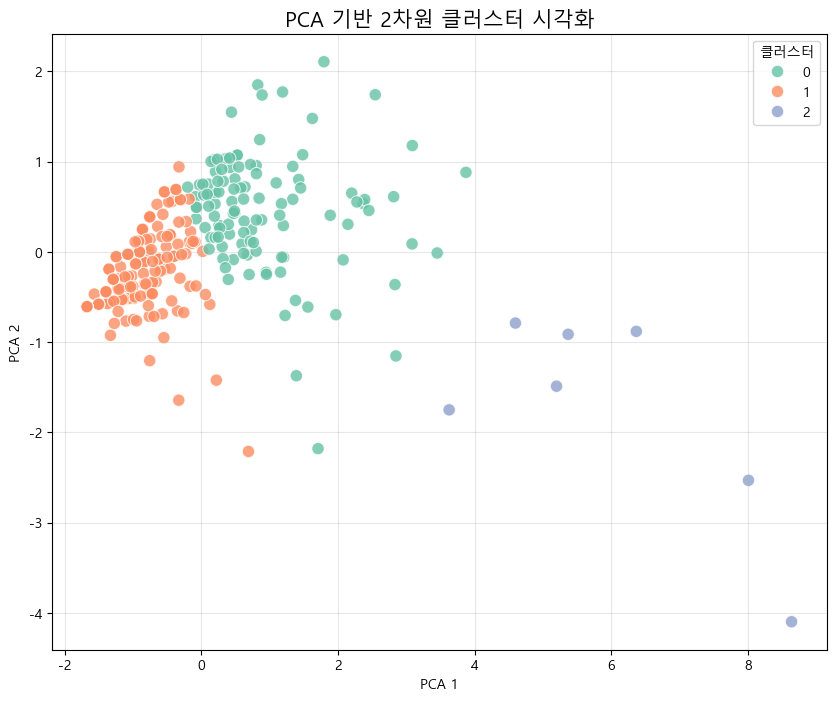

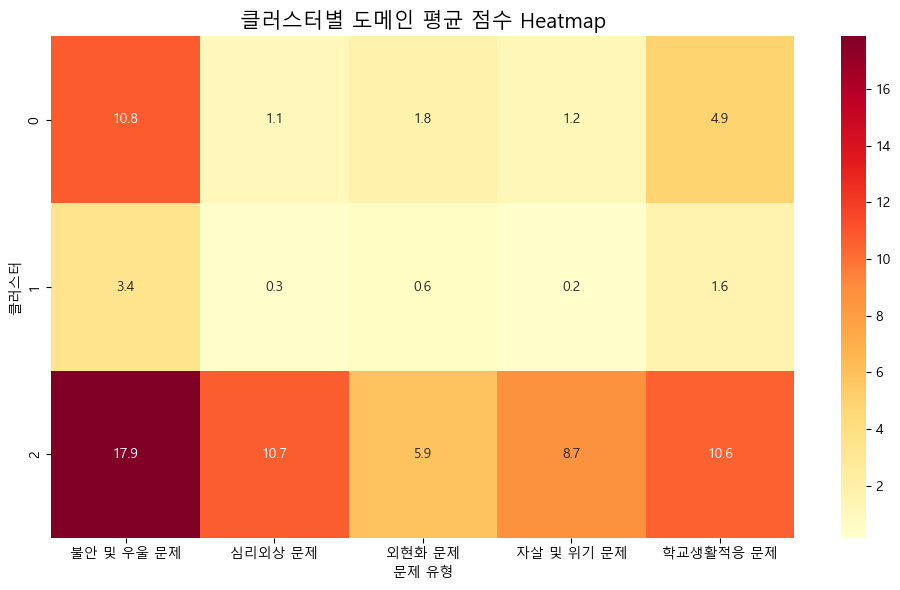

C:\Users\user\AppData\Local\Temp\ipykernel_23436\1012236522.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='cluster', y='totalScore', palette='Set2')


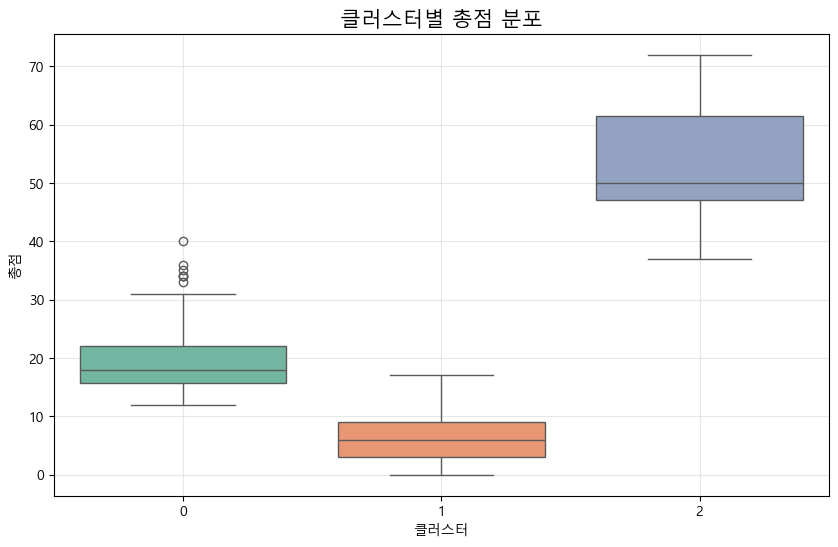

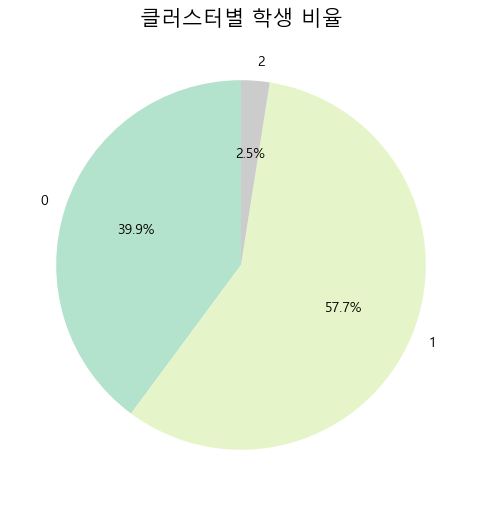

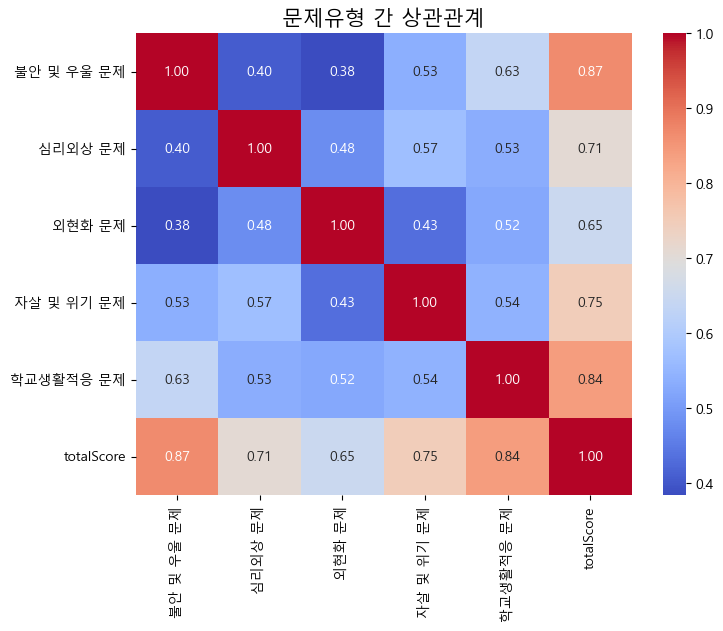

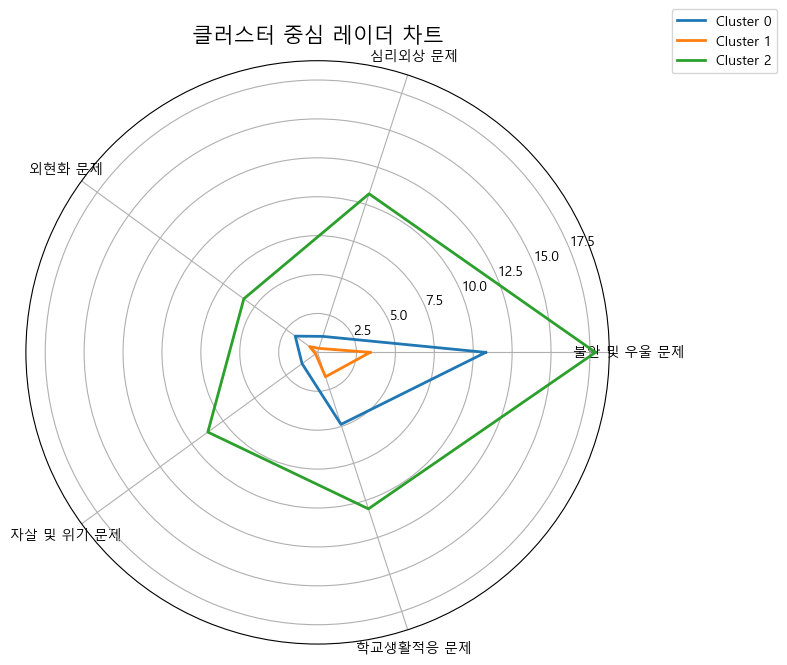

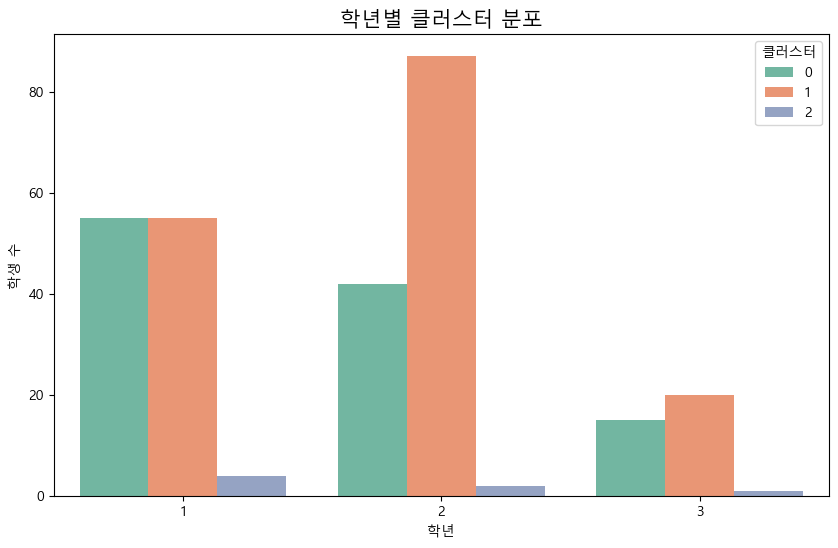

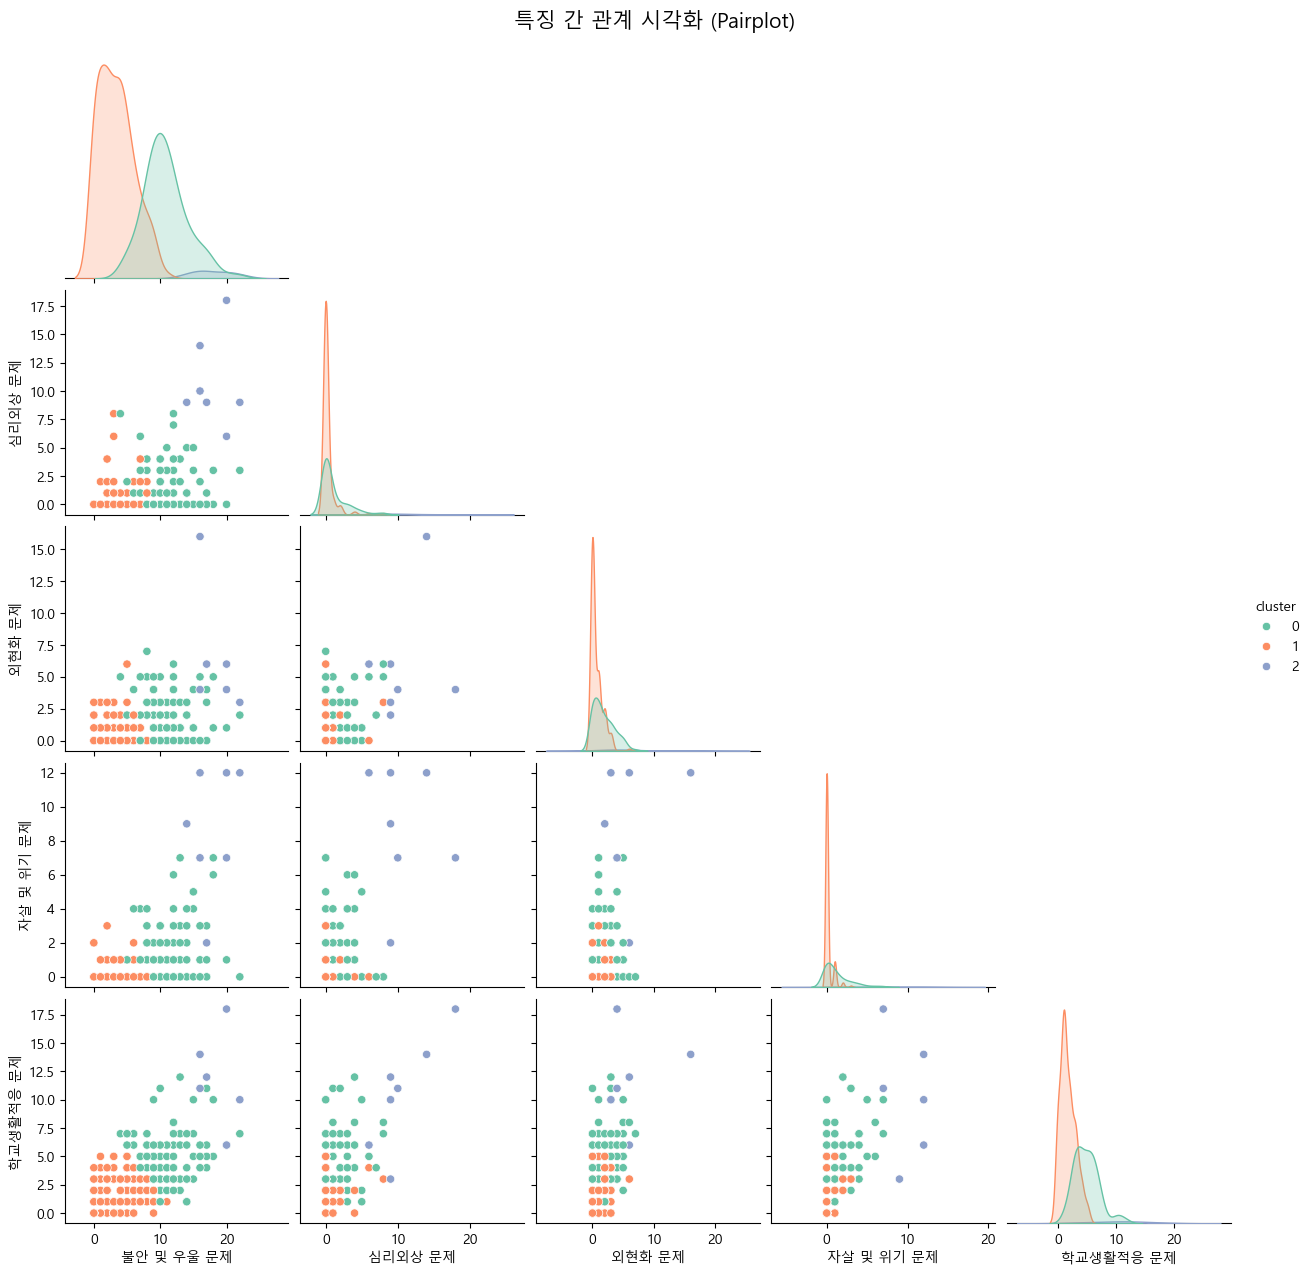

C:\Users\user\AppData\Local\Temp\ipykernel_23436\1012236522.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='F-value', y='Feature', palette='YlGnBu')


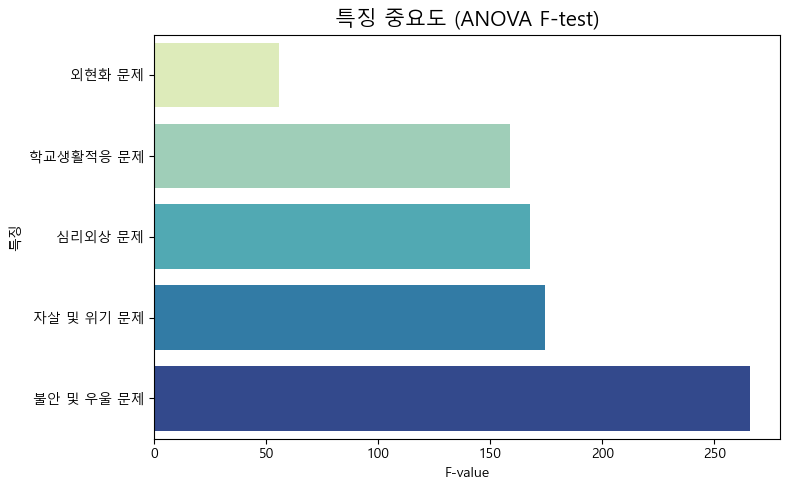

In [6]:
# ==========================================
# 4. 추가 시각화: 클러스터 분석 심화
# ==========================================

from math import pi
import matplotlib.cm as cm

# ---------------------------
# (1) PCA 시각화 (2차원 공간)
# ---------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_filtered)
df_filtered['pca1'] = X_pca[:, 0]
df_filtered['pca2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
palette = sns.color_palette("Set2", optimal_k)
sns.scatterplot(data=df_filtered, x='pca1', y='pca2',
                hue='cluster', palette=palette, s=80, alpha=0.8)
plt.title('PCA 기반 2차원 클러스터 시각화', fontsize=15, fontfamily='Malgun Gothic')
plt.xlabel('PCA 1', fontfamily='Malgun Gothic')
plt.ylabel('PCA 2', fontfamily='Malgun Gothic')
plt.legend(title='클러스터', prop={'family': 'Malgun Gothic'})
plt.grid(True, alpha=0.3)
plt.show()


# ---------------------------
# (2) 클러스터별 도메인 평균 히트맵
# ---------------------------
plt.figure(figsize=(10, 6))
cluster_mean = df_filtered.groupby('cluster')[features].mean().sort_index()
sns.heatmap(cluster_mean, annot=True, cmap='YlOrRd', fmt=".1f")
plt.title('클러스터별 도메인 평균 점수 Heatmap', fontsize=15, fontfamily='Malgun Gothic')
plt.xlabel('문제 유형', fontfamily='Malgun Gothic')
plt.ylabel('클러스터', fontfamily='Malgun Gothic')
plt.tight_layout()
plt.show()


# ---------------------------
# (3) 클러스터별 TotalScore 분포
# ---------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filtered, x='cluster', y='totalScore', palette='Set2')
plt.title('클러스터별 총점 분포', fontsize=15, fontfamily='Malgun Gothic')
plt.xlabel('클러스터', fontfamily='Malgun Gothic')
plt.ylabel('총점', fontfamily='Malgun Gothic')
plt.grid(True, alpha=0.3)
plt.show()


# ---------------------------
# (4) 클러스터별 학생 수 비율 파이차트
# ---------------------------
plt.figure(figsize=(6, 6))
cluster_counts.plot.pie(autopct='%1.1f%%', startangle=90,
                        cmap='Pastel2', legend=False)
plt.title('클러스터별 학생 비율', fontsize=15, fontfamily='Malgun Gothic')
plt.ylabel('')
plt.show()


# ---------------------------
# (5) 각 문제유형 간 상관관계 히트맵
# ---------------------------
corr = df_filtered[features + ['totalScore']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('문제유형 간 상관관계', fontsize=15, fontfamily='Malgun Gothic')
plt.show()


# ---------------------------
# (6) 클러스터 중심값 레이더 차트
# ---------------------------

categories = features
num_vars = len(categories)
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
for i, row in cluster_centers_df.iterrows():
    values = row.values.flatten().tolist()
    values += values[:1]
    plt.polar(angles, values, label=f'Cluster {i}', linewidth=2)

plt.xticks(angles[:-1], categories, fontfamily='Malgun Gothic')
plt.title('클러스터 중심 레이더 차트', fontsize=15, fontfamily='Malgun Gothic')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1),
           prop={'family': 'Malgun Gothic'})
plt.tight_layout()
plt.show()


# ---------------------------
# (7) Grade × Cluster 분포 (교차 막대그래프)
# ---------------------------
plt.figure(figsize=(10, 6))
sns.countplot(data=df_filtered, x='grade_num', hue='cluster', palette='Set2')
plt.title('학년별 클러스터 분포', fontsize=15, fontfamily='Malgun Gothic')
plt.xlabel('학년', fontfamily='Malgun Gothic')
plt.ylabel('학생 수', fontfamily='Malgun Gothic')
plt.legend(title='클러스터', prop={'family': 'Malgun Gothic'})
plt.show()


# ---------------------------
# (8) Gender × Cluster 분포 (성별 비교)
# ---------------------------
if 'gender' in df_filtered.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_filtered, x='gender', hue='cluster', palette='Set3')
    plt.title('성별에 따른 클러스터 분포', fontsize=15, fontfamily='Malgun Gothic')
    plt.xlabel('성별', fontfamily='Malgun Gothic')
    plt.ylabel('학생 수', fontfamily='Malgun Gothic')
    plt.legend(title='클러스터', prop={'family': 'Malgun Gothic'})
    plt.show()


# ---------------------------
# (9) Pairplot (특징 간 관계)
# ---------------------------
sns.pairplot(df_filtered, vars=features, hue='cluster',
             palette='Set2', corner=True)
plt.suptitle('특징 간 관계 시각화 (Pairplot)', fontsize=15,
             fontfamily='Malgun Gothic', y=1.02)
plt.show()


# ---------------------------
# (10) Feature Importance (ANOVA F-test)
# ---------------------------
f_values, p_values = f_classif(X_scaled_filtered, df_filtered['cluster'])
importance_df = pd.DataFrame({'Feature': features, 'F-value': f_values})
importance_df.sort_values('F-value', ascending=True, inplace=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='F-value', y='Feature', palette='YlGnBu')
plt.title('특징 중요도 (ANOVA F-test)', fontsize=15, fontfamily='Malgun Gothic')
plt.xlabel('F-value', fontfamily='Malgun Gothic')
plt.ylabel('특징', fontfamily='Malgun Gothic')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.feature_selection import f_classif
question_cols = [c for c in df.columns
                 if c not in ['id', 'studentGrade', 'totalScore', 'grade_num', 'is_outlier', 'cluster']]


Xq = df_filtered[question_cols]
yq = df_filtered['cluster']

f_vals, p_vals = f_classif(Xq, yq)

question_importance = pd.DataFrame({
    'question': question_cols,
    'F_value': f_vals,
    'p_value': p_vals
}).sort_values('F_value', ascending=False)

print(question_importance.head(10))

     question     F_value       p_value
0  불안 및 우울 문제  265.927460  2.841989e-65
3  자살 및 위기 문제  174.278791  8.803373e-50
1     심리외상 문제  167.877424  1.552139e-48
4   학교생활적응 문제  158.861185  9.797684e-47
2      외현화 문제   55.557385  5.028335e-21
